# 01 - Image Data Foundation For Inspection AI

**Purpose:** Establish the image data concepts used by VisionInspect AI: pixels, resolution, channels, grayscale/binary views, and intensity distribution.

**Expected output:** Real MVTec bottle image, pixel inspection table, grayscale/binary conversion, histogram, and in-memory format comparison.

**Platform connection:** These are the low-level signals used later by preprocessing, anomaly maps, masks, heatmaps, and model input tensors.


In [1]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
IMAGE_SIZE = (256, 256)
LABELS = ["good", "broken_large", "broken_small", "contamination"]


def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def first_image(label="contamination", split="test"):
    folder = BOTTLE_DIR / split / label
    images = sorted(folder.glob("*.png"))
    if not images:
        raise FileNotFoundError(f"No images found in {folder}")
    return images[0]


def show_grid(items, cols=4, figsize=(14, 7), suptitle=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, image, cmap = item
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Project root:", PROJECT_ROOT)
print("MVTec bottle folder exists:", BOTTLE_DIR.exists())


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
MVTec bottle folder exists: True


## Real Image Used


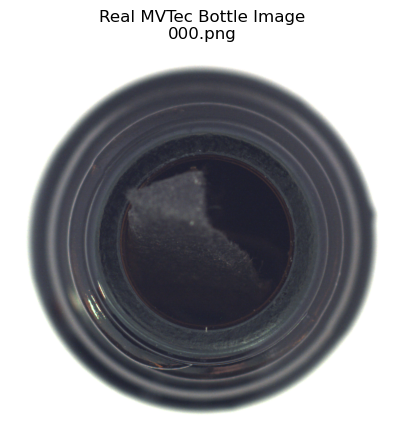

,image_path,height,width,channels,resolution,dtype
0,C:\Users\HP\Desktop\springboard\visioninspect-...,900,900,3,900 x 900,uint8


In [2]:
image_path = first_image("contamination", "test")
image_rgb = read_rgb(image_path)
height, width, channels = image_rgb.shape

plt.figure(figsize=(5, 5))
plt.imshow(image_rgb)
plt.title(f"Real MVTec Bottle Image\n{image_path.name}")
plt.axis("off")
plt.show()

display(pd.DataFrame([{
    "image_path": str(image_path),
    "height": height,
    "width": width,
    "channels": channels,
    "resolution": f"{width} x {height}",
    "dtype": str(image_rgb.dtype),
}]))


## Pixels, Resolution, And Channels


,y,x,red,green,blue,mean_intensity
0,450,450,59,53,61,57.67
1,300,300,40,46,53,46.33
2,225,675,74,68,78,73.33
3,675,225,44,46,59,49.67


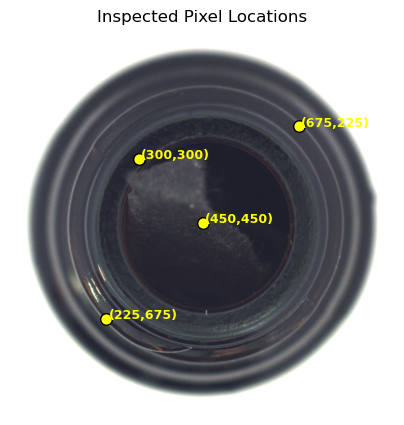

In [3]:
points = [(height // 2, width // 2), (height // 3, width // 3), (height // 4, 3 * width // 4), (3 * height // 4, width // 4)]
rows = []
for y, x in points:
    r, g, b = image_rgb[y, x]
    rows.append({"y": y, "x": x, "red": int(r), "green": int(g), "blue": int(b), "mean_intensity": round(float(np.mean([r, g, b])), 2)})
display(pd.DataFrame(rows))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image_rgb)
for y, x in points:
    ax.scatter(x, y, s=70, c="yellow", edgecolors="black")
    ax.text(x + 5, y, f"({x},{y})", color="yellow", fontsize=9, weight="bold")
ax.set_title("Inspected Pixel Locations")
ax.axis("off")
plt.show()


## RGB, Grayscale, Binary, And Intensity


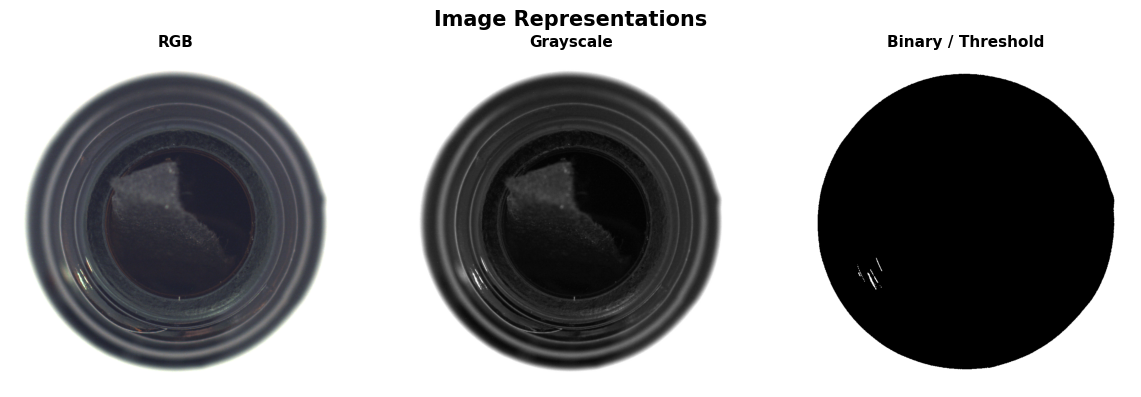

,representation,shape,channels,value_range,unique_values
0,RGB,"(900, 900, 3)",3,25 - 255,NaN
1,Grayscale,"(900, 900)",1,28 - 255,NaN
2,Binary,"(900, 900)",1,NaN,"[0, 255]"


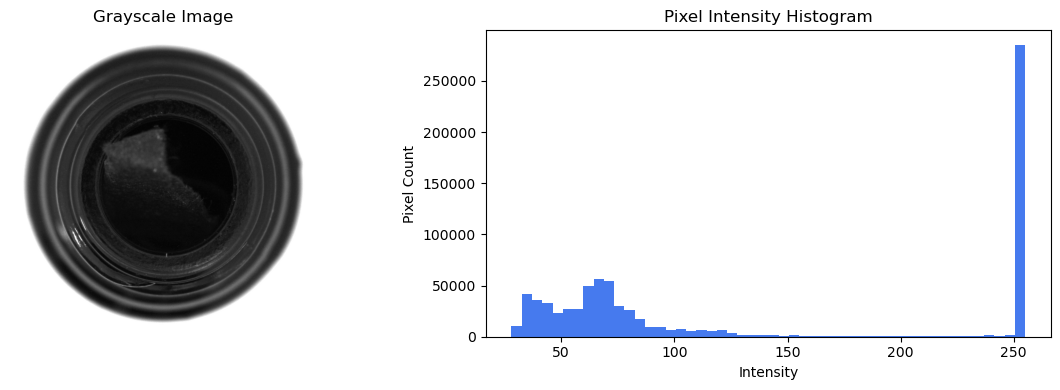

In [4]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
show_grid([("RGB", image_rgb, None), ("Grayscale", gray, "gray"), ("Binary / Threshold", binary, "gray")], cols=3, figsize=(12, 4), suptitle="Image Representations")

display(pd.DataFrame([
    {"representation": "RGB", "shape": str(image_rgb.shape), "channels": 3, "value_range": f"{image_rgb.min()} - {image_rgb.max()}"},
    {"representation": "Grayscale", "shape": str(gray.shape), "channels": 1, "value_range": f"{gray.min()} - {gray.max()}"},
    {"representation": "Binary", "shape": str(binary.shape), "channels": 1, "unique_values": sorted(np.unique(binary).tolist())},
]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale Image")
axes[0].axis("off")
axes[1].hist(gray.ravel(), bins=50, color="#2563eb", alpha=0.85)
axes[1].set_title("Pixel Intensity Histogram")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Pixel Count")
plt.tight_layout()
plt.show()


## In-Memory Format Comparison


In [5]:
image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
rows = []
for ext in [".png", ".jpg", ".bmp", ".tiff"]:
    success, encoded = cv2.imencode(ext, image_bgr)
    rows.append({"format": ext.upper().replace(".", ""), "encoded_success": bool(success), "in_memory_kb": round(len(encoded) / 1024, 2) if success else None})
display(pd.DataFrame(rows))


,format,encoded_success,in_memory_kb
0,PNG,True,669.01
1,JPG,True,134.89
2,BMP,True,2373.10
3,TIFF,True,790.55


## Defect Signal At Pixel Level

A defect is not magic to the model. It appears as a measurable change in local pixel intensity, color, texture, or edges.


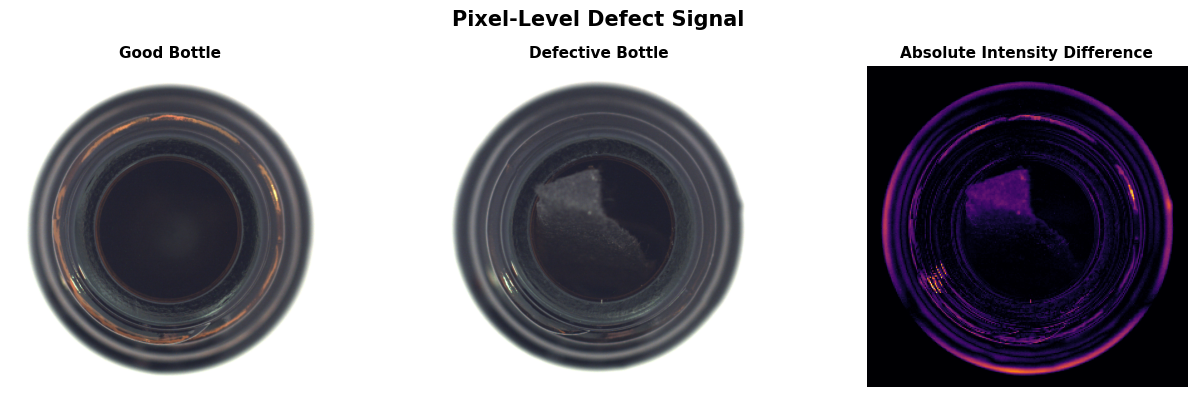

,good_mean_intensity,defective_mean_intensity,difference_mean,difference_p95,why_it_matters
0,136.88,135.94,11.3,48.0,large local differences become anomaly-map evi...


In [6]:
good_img = read_rgb(first_image("good", "test"))
defect_img = read_rgb(first_image("contamination", "test"))
good_gray = cv2.cvtColor(cv2.resize(good_img, IMAGE_SIZE), cv2.COLOR_RGB2GRAY)
defect_gray = cv2.cvtColor(cv2.resize(defect_img, IMAGE_SIZE), cv2.COLOR_RGB2GRAY)
absolute_difference = cv2.absdiff(good_gray, defect_gray)

show_grid([
    ("Good Bottle", good_img, None),
    ("Defective Bottle", defect_img, None),
    ("Absolute Intensity Difference", absolute_difference, "inferno"),
], cols=3, figsize=(13, 4), suptitle="Pixel-Level Defect Signal")

display(pd.DataFrame([{
    "good_mean_intensity": round(float(good_gray.mean()), 2),
    "defective_mean_intensity": round(float(defect_gray.mean()), 2),
    "difference_mean": round(float(absolute_difference.mean()), 2),
    "difference_p95": round(float(np.percentile(absolute_difference, 95)), 2),
    "why_it_matters": "large local differences become anomaly-map evidence",
}]))


## Validation Outcome

- The project works with real image matrices.
- Width, height, channels, and intensity directly affect preprocessing and inference.
- Grayscale, binary masks, and histograms explain why anomaly maps work.
